# N-Gram Analysis
This notebook aims at investigating the most frequent n-grams in music-related YouTube videos.

In [ ]:
import os
import pandas as pd
from tqdm import tqdm
import json

with open(os.path.join("data", "dvi2", "dataset", "train.json"), "r") as f:
    train_data = json.load(f)
    
path = os.path.join("data", "analysis", "df.parquet")
if not os.path.isfile(path):
    print("Loading DVI2 dataset...")
    dvi2_path = os.path.join("data", "dvi2", "dataset", "matched", "dvi_fm_filtered.jsonl")
    df_dvi2 = pd.read_json(dvi2_path, lines=True, orient="records")
    # Explode versions
    df_exp = df_dvi2.explode("versions")
    df_exp = pd.concat(
        [df_exp[["clique_id"]].reset_index(drop=True),
        pd.json_normalize(df_exp["versions"])],
        axis=1
    )
    df_exp = df_exp.explode("tracks").reset_index(drop=True)
    df_exp = pd.concat(
        [df_exp[["clique_id", "version_id"]],
        pd.json_normalize(df_exp["tracks"])],
        axis=1
    )
    df_exp = df_exp.explode("youtube_video").reset_index(drop=True)
    df_dvi2 = pd.concat(
        [df_exp,
        pd.json_normalize(df_exp["youtube_video"])],
        axis=1
    )
    df_dvi2 = df_dvi2.drop_duplicates(subset=["clique_id", "version_id", "url"])
    def get_youtube_id(row):
        if pd.isna(row["url"]):
            return row["version_id"]
        else:
            return row["url"].split("watch?v=")[-1]
    df_dvi2["youtube_id"] = df_dvi2.apply(get_youtube_id, axis=1)

    print("Loading YT data...")
    df_yt = pd.read_parquet(os.path.join("data", "yt.parquet")).reset_index(drop=True)

    df = pd.merge(df_dvi2, df_yt, on="youtube_id", how="left")
    df = df.dropna(subset=["title", "description"])
else:
    print("Loading preprocessed data...")
    df = pd.read_parquet(path)

df = df.loc[df.clique_id.isin(train_data)]


### Clique stopwords (title, artist, writers)

In [ ]:
def concat_fields(row):
    title, writers, artists = row.track_title, row.track_writer_names, row.track_artist_names
    return [title] + (writers if isinstance(writers, list) else [""]) + (artists if isinstance(artists, list) else [""])

print("Concatenating fields for stopwords...")
df.loc[:, "clique_stopwords"] = df.apply(concat_fields, axis=1)

def to_unigrams_without_stopwords(fields):
    unigrams = []
    for s in fields:
        if isinstance(s, str):
            tokens = s.lower().split()  # split string into unigrams
            unigrams.extend([t for t in tokens])
    return unigrams

print("Converting to unigrams...")
df["clique_stopwords"] = df["clique_stopwords"].apply(to_unigrams_without_stopwords)

print("Aggregating stopwords per clique...")
df_stopwords = df[["clique_id", "clique_stopwords"]].groupby("clique_id").agg(
    {"clique_stopwords": lambda x: list(set([item for sublist in x for item in sublist]))}
).reset_index()


In [ ]:
from rapidfuzz import fuzz

def mask_stopwords(text, stopwords, threshold=90):
    if not isinstance(text, str) or not stopwords:
        return text
    tokens = text.split()
    masked = []
    for token in tokens:
        found = False
        for sw in stopwords:
            if sw and fuzz.token_sort_ratio(token.lower(), sw.lower()) >= threshold:
                found = True
                break
        masked.append("[MASK]" if found else token)
    return " ".join(masked)

def mask_stopwords_list(tags, stopwords, threshold=90):
    if not isinstance(tags, list) or not stopwords:
        return tags
    masked = []
    for tag in tags:
        found = False
        for sw in stopwords:
            if sw and fuzz.token_sort_ratio(str(tag).lower(), sw.lower()) >= threshold:
                found = True
                break
        masked.append("[MASK]" if found else tag)
    return masked

# Prepare stopword mapping
stopword_map = dict(zip(df_stopwords.clique_id, df_stopwords.clique_stopwords))

tqdm.pandas(desc="Masking stopwordss")
df["title2"] = df.progress_apply(lambda row: mask_stopwords(row["title"], stopword_map.get(row["clique_id"], [])), axis=1)
df["description2"] = df.progress_apply(lambda row: mask_stopwords(row["description"], stopword_map.get(row["clique_id"], [])), axis=1)
df["tags2"] = df.progress_apply(lambda row: mask_stopwords_list(row["tags"] if "tags" in row else [], stopword_map.get(row["clique_id"], [])), axis=1)


### Stemming + Extraction

In [ ]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import stopwordsiso as stopwords
import nltk
from tqdm import tqdm
import re

nltk.download('punkt')

from preprocessing.string_processor import StringProcessor

processor = StringProcessor()

# Build a multilingual stopword set
stopword_set = set()
stopword_set.update("[mask]")
for lang in stopwords.langs():
    stopword_set.update(stopwords.stopwords("zh"))

def tokenize_and_filter(text, processor=lambda x: x):
    if not isinstance(text, str):
        return []
    text = processor(text)  # Preprocess
    tokens = word_tokenize(text.lower())
    # Filter out stopwords
    tokens = [t for t in tokens if t not in stopword_set]
    return tokens

def extract_ngrams(tokens, n):
    return ['_'.join(ng) for ng in ngrams(tokens, n)]

def get_all_ngrams(text, processor=lambda x: x):
    tokens = tokenize_and_filter(text, processor=processor)
    return {
        '1grams': extract_ngrams(tokens, 1),
        '2grams': extract_ngrams(tokens, 2),
        '3grams': extract_ngrams(tokens, 3)
    }

def process_column(df, colname, processor=lambda x: x):
    tqdm.pandas(desc=f"Processing {colname}")
    df.loc[:,f'{colname}_1grams'] = df[colname].progress_apply(lambda x: get_all_ngrams(x, processor)['1grams'])
    df.loc[:,f'{colname}_2grams'] = df[colname].progress_apply(lambda x: get_all_ngrams(x, processor)['2grams'])
    df.loc[:,f'{colname}_3grams'] = df[colname].progress_apply(lambda x: get_all_ngrams(x, processor)['3grams'])

def process_tags_column(df, colname, processor=lambda x: x):
    def process_tag_list(taglist):
        if not isinstance(taglist, list):
            return [], [], []
        tokens = []
        for tag in taglist:
            tag = processor(tag)
            tokens.extend(tokenize_and_filter(tag, processor=processor))  # Fixed: pass the correct processor
        return (
            extract_ngrams(tokens, 1),
            extract_ngrams(tokens, 2),
            extract_ngrams(tokens, 3)
        )
    
    tqdm.pandas(desc=f"Processing {colname} (tags)")
    results = df[colname].apply(list).progress_apply(process_tag_list)
    df[f'{colname}_1grams'] = results.progress_apply(lambda x: x[0])
    df[f'{colname}_2grams'] = results.progress_apply(lambda x: x[1])
    df[f'{colname}_3grams'] = results.progress_apply(lambda x: x[2])

def preprocess(text):
    text = text.replace("[MASK]", " ")
    text = processor(text).lower()
    text = re.sub(r"[^\w\s]|_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Run processing
process_column(df, "title2", processor=preprocess)
process_column(df, "description2", processor=preprocess)
process_tags_column(df, "tags2", processor=preprocess)


### Most frequent N-Grams

In [ ]:
from collections import Counter
from nltk.corpus import stopwords
import numpy as np

# Download stopwords if not already
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Filter columns ending with _1gram, _2gram, or _3gram
target_cols = [col for col in df.columns if any(suffix in col for suffix in ['_1gram', '_2gram', '_3gram'])]

result = {}

for col in tqdm(target_cols):
    all_strings = []

    for item in df[col].dropna():
        if isinstance(item, (list, np.ndarray)):
            tokens = item
        else:
            tokens = [item]

        for token in tokens:
            if isinstance(token, str) and token.lower() not in stop_words:
                all_strings.append(token)

    result[col] = dict(Counter(all_strings).most_common())

outpath = os.path.join("data", "analysis", "ngram_counts.json")
with open(outpath, "w") as f:
    json.dump(result, f, indent=4, ensure_ascii=False)
print(f"N-gram counts saved to  {outpath}")


In [ ]:
df_ngrams = pd.DataFrame.from_dict(result, orient='columns')#.fillna(0).astype(int)
df_ngrams = df_ngrams.reset_index().melt(id_vars='index', var_name='field', value_name='count')
df_ngrams = df_ngrams.rename(columns={'index': 'ngram'})
df_ngrams = df_ngrams.dropna(subset=['count'])
df_ngrams = df_ngrams[df_ngrams['count'] > 1]
print("Grouping n-grams...")
df_ngrams = (
    df_ngrams.groupby("ngram")
      .agg({
          "count": "sum",
          "field": lambda x: {field: cnt for field, cnt in zip(x, df_ngrams.loc[x.index, 'count'])}
      })
      .reset_index()
)
df_ngrams = df_ngrams.groupby("ngram").agg(list)
df_ngrams["total"] = df_ngrams["count"].apply(sum)
df_ngrams["counts"] = df_ngrams.apply(lambda row: {
    field: count for field, count in zip(row["field"], row["count"])
}, axis=1)
df_ngrams = df_ngrams.drop(columns=["field", "count"]).sort_values(by="total", ascending=False).reset_index()
df_ngrams.head(10_000).to_csv(os.path.join("data", "analysis", "top10000ngrams.csv"), index=False)
df_ngrams.to_parquet(os.path.join("data", "analysis", "ngram_counts.parquet"), index=False)


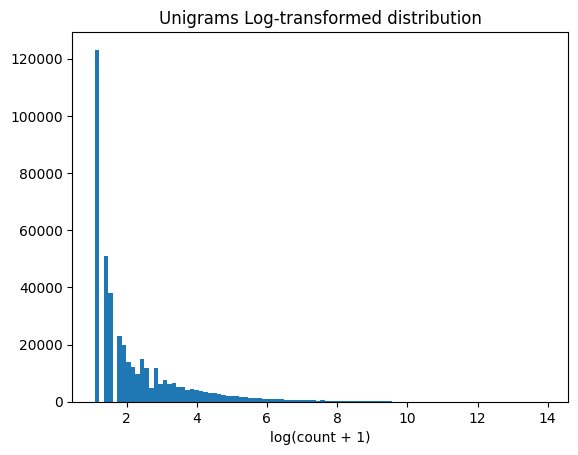


Quantiles: 
0.250        2.00
0.500        5.00
0.750       14.00
0.900       59.00
0.990     1466.00
0.999    15661.98
Name: total, dtype: float64

Statistics for unigrams:
Mean: 120.06011415173212
Median: 5.0
Std: 3323.426215460061
Max: 1139368.0
99.9% quantile: 15661.980000001146


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_uni = df_ngrams.loc[
    df_ngrams['ngram'].str.count('_') == 0].sort_values('total', ascending=False)

plt.hist(np.log1p(df_uni.total), bins=100)  # log(1 + x) avoids log(0)
plt.title("Unigrams Log-transformed distribution")
plt.xlabel("log(count + 1)")
plt.show()

print("\nQuantiles: ")
q = df_uni.total.quantile([0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
print(q)

print("\nStatistics for unigrams:")
print("Mean:", df_uni.total.mean())
print("Median:", df_uni.total.median())
print("Std:", df_uni.total.std())
print("Max:", df_uni.total.max())
print("99.9% quantile:", df_uni.total.quantile(0.999))



### After annotation

In [232]:
df_ngrams_annotated = pd.read_csv(
    os.path.join("data", "analysis", "top10000ngrams_annotated.csv"))

count_1gram_at_1000 = df_ngrams_annotated.loc[(df_ngrams_annotated.ngram_rank == 1000) & 
                        (df_ngrams_annotated.type == "1gram"), "total"].values.item()
print(f"Unigram at rank 1,000 has {int(count_1gram_at_1000):,} occurrences.")
count_ngram_at_1000 = df_ngrams_annotated.loc[999, "total"].item()
print(f"N-gram at rank 1,000 has {int(count_ngram_at_1000):,} occurrences.")

df_ngrams_annotated[["category", "ngram"]].groupby("category").agg(list)


Unigram at rank 1,000 has 7,389 occurrences.
N-gram at rank 1,000 has 10,119 occurrences.


,ngram
category,
-,"[youtube, https, com, by_youtube, provided, yo..."
acoustic,[acoustic]
artist_type,"[band, orchestra, his_orchestra, trio, and_his..."
auto_generated,"[auto, generated, auto_generated, generated_by..."
background,"[background, backing]"
cover,"[cover, covers, guitar_cover, cover_of, cover_by]"
dance,"[dance, dancing]"
general,"[music, song, songs, artist, musical, version,..."
genre,"[jazz, rock, blues, country, pop, classic, blu..."


### Cleaning up concepts
- **drop**: We drop concepts that are too general or not helpful (e.g. release type).
- **rename**: We rename some concepts and we merge various concepts to *studio*.
- **add**: We add some additional cues.

In [255]:
drop = ["-", "general", "hq", "music_company_label", "original", "dance",
        "recording", "release_info", "release_type", "tabs", "writer_artist_mentioned"]

rename = {
    "auto_generated": "professional", # NOTE: auto-generated content is often studio
    "remastered": "studio",
    "lyrics": "studio",
    "official": "studio",  # NOTE: Assuming official videos are studio recordings
    "reaction": "secondary",  # NOTE: category to capture reactions, analyses, etc.
    
    # NOTE: bands, orchestras, instruments into one group
    "artist_type": "instrument_group", 
    "instrument_vocals": "instrument_group",
}

df_concepts = df_ngrams_annotated[~df_ngrams_annotated["category"].isin(drop)].copy()
df_concepts["category"] = df_concepts["category"].replace(rename)
df_concepts = df_concepts[["category", "ngram"]].groupby("category", as_index=False).agg(list)

# make dict and add some additional cues
concept_dict = dict(zip(df_concepts["category"], df_concepts["ngram"]))
concept_dict["cover"].append("interpretation")
concept_dict["remix"].append("mashup")
concept_dict["segment"].append("verse")
concept_dict["segment"].append("intro")
concept_dict["segment"].append("outro")
concept_dict["segment"].append("bridge")
concept_dict["secondary"].append("analysis")
concept_dict["secondary"].append("review")
concept_dict["tutorial"].append("instruction")
df_concepts


,category,ngram
0,acoustic,[acoustic]
1,background,"[background, backing]"
2,cover,"[cover, covers, guitar_cover, cover_of, cover_..."
3,genre,"[jazz, rock, blues, country, pop, classic, blu..."
4,instrument_group,"[guitar, bass, band, piano, orchestra, vocals,..."
5,instrumental,"[karaoke, instrumental, karaoke_version]"
6,live,"[live, show, concert, live_at, festival, perfo..."
7,professional,"[auto, generated, auto_generated, generated_by..."
8,remix,"[remix, mashup]"
9,secondary,"[first, reaction, first_time, analysis, review]"


### Add conjugation and plural variants


In [ ]:
import spacy
import nltk
from itertools import chain

# Load English spaCy model
nlp = spacy.load("en_core_web_sm")


def get_spacy_variants(word):
    # Just base form and standard inflections using POS
    doc = nlp(word)
    if not doc:
        return set()

    token = doc[0]
    base = token.lemma_

    variants = {word, base}
    
    # Include verb conjugations if it's a verb
    if token.pos_ == "VERB":
        variants.update({base + "s", base + "ed", base + "ing"})
    
    # Include plural if noun
    elif token.pos_ == "NOUN":
        if not base.endswith("s"):
            variants.add(base + "s")

    return variants

def expand_concepts(concept_dict):
    result = {}

    for concept, cues in tqdm(concept_dict.items(), desc="Expanding concepts", total=len(concept_dict)):
        variants = set()

        for cue in cues:
            cue_variants = get_spacy_variants(cue)
            variants.update(cue_variants)

        result[concept] = list(variants)
    return result

concept_dict2 = expand_concepts(concept_dict)

with open(os.path.join("data", "analysis", "concepts", "concepts.json"), "w") as f:
    json.dump(concept_dict2, f, indent=4, ensure_ascii=False)


Expanding concepts: 100%|██████████| 13/13 [00:00<00:00, 41.02it/s]


### Translate to most frequent European languages
We use *Qwen3* to translate the cues into other languages.


##### Prompt
*You are an expert translator for the domain of online music videos. You are given a mapping of concepts in the domain each mapping to different cues (most of them in English language). Please translate these cues each into the major European languages: Spanish, French, German, Italien, and Portuguese. Avoid translations being too general and make sure that these conform with the domain of online music videos.* 

In [ ]:
import json
import os
import yaml

multilingual_concepts = {}
multiclass_concepts = ["genre", "instrument_group", "segment"]

with open(os.path.join("data", "analysis", "concepts", "concepts.json"), "r") as f:
    concepts = json.load(f) 

# collect
for concept, cues in concepts.items():
    # NOTE: we omit these multiclass concepts
    if not concept in multiclass_concepts:
        multilingual_concepts[concept] = {
            "original": cues,
        }    
    

concepts_dir = os.path.join("data", "analysis", "concepts")

languages = ["es", "fr", "de", "it", "pt"]

# add translations for each language
for lang in languages:
    with open(os.path.join(concepts_dir, f"concepts_{lang}.json"), "r") as f:
        concepts_lang = json.load(f)
    for concept, cues in concepts_lang.items():
        if concept not in multiclass_concepts:
            multilingual_concepts[concept][lang] = cues

# sort and remove duplicates
for concept, langs in multilingual_concepts.items():
    # Remove duplicates and sort cues for each language
    for lang in langs:
        multilingual_concepts[concept][lang] = sorted(set(langs[lang]))

    # Reorder the languages: "original" first, then in the order of the `languages` list
    ordered_langs = ["original"] + languages
    multilingual_concepts[concept] = {
        k: multilingual_concepts[concept][k]
        for k in ordered_langs if k in multilingual_concepts[concept]
    }

with open(os.path.join(concepts_dir, "concepts.yaml"), "w") as f:
    yaml.dump(multilingual_concepts, f, allow_unicode=True, default_flow_style=False, sort_keys=False)
    

### Cleaning Multi-Class concepts
Multi-class concepts are *genres*, *instruments_groups* (*instruments* and *musical groups*) and *segments*. For these, we first curate the list of values manually, since in cases of *genres* the plurals are not meaningful. Then, we translate all of these into the same languages as above.

In [ ]:
def clean_dict(data):
    """Cleans a nested dict as described."""
    if not isinstance(data, dict):
        return data

    cleaned = {}
    for key in sorted(data.keys()):
        value = data[key]

        if isinstance(value, dict):
            # Recurse into sub-dictionaries
            cleaned[key] = clean_dict(value)

        elif isinstance(value, list):
            # Clean list: remove duplicates, convert to snake_case, and sort
            cleaned_list = sorted(
                {item.lower() for item in value if isinstance(item, str)}
            )
            cleaned[key] = cleaned_list

        else:
            cleaned[key] = value

    return cleaned

for file in ["genres", "instruments_groups", "segments"]:
    with open(os.path.join(concepts_dir, f"{file}.json"), "r") as f:
        data = json.load(f)

    cleaned_data = clean_dict(data)
    
    with open(os.path.join(concepts_dir, f"{file}.yaml"), "w") as f:
        yaml.dump(cleaned_data, f, allow_unicode=True, default_flow_style=False, sort_keys=False)
